In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
     Input
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [3]:
df = pd.read_json(
    "dataset_Analyse_des_sentiments_clean.json"
)

In [4]:
df.head()

,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


In [5]:
df.columns

Index(['Date', 'Auteur', 'Note', 'Version', 'Titre', 'Commentaire', 'Votes',
       'satisfaction', 'YearMonth', 'word_count', 'clean_commentaire',
       'clean_Titre'],
      dtype='object')

In [6]:
df["full_text"] = (

    df["clean_Titre"].astype(str)

    + " "

    + df["clean_commentaire"].astype(str)
)

In [7]:
df[["full_text", "satisfaction"]].head()

,full_text,satisfaction
0,bonne app mais belle interface sur iphone manq...,neutral
1,pas assez intuitive trouve que nouvelle appli ...,negative
2,tres bon produit instantanement intelligent co...,positive
3,parfait tres utile plus besoin penser faut fai...,positive
4,arretez mise jour intempestive svp app est sim...,neutral


# **ENCODER LES LABELS**

In [8]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["satisfaction"]
)

In [9]:
print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [10]:
MAX_WORDS = 10000

tokenizer = Tokenizer(

    num_words=MAX_WORDS,

    oov_token="<OOV>"
)

In [11]:
tokenizer.fit_on_texts(
    df["full_text"]
)

In [12]:
sequences = tokenizer.texts_to_sequences(
    df["full_text"]
)

In [13]:
print(
    sequences[:3]
)

[[57, 67, 14, 688, 201, 13, 120, 55, 130, 126, 154, 7, 155, 240, 1054, 10, 187, 35, 187, 169, 116, 109, 241, 16, 34, 58, 9, 67, 131, 9, 156, 512], [2, 170, 95, 188, 10, 110, 24, 3, 87, 2, 95, 25, 111, 202, 96, 6, 189, 513, 8, 81, 342, 6, 308, 222, 46, 6, 1055, 689, 271, 5, 15, 426, 2, 101, 111, 690, 7, 10, 4, 82, 51, 72], [8, 132, 121, 1056, 1057, 242]]


In [14]:
MAX_LEN = 100

X = pad_sequences(

    sequences,

    maxlen=MAX_LEN,

    padding='post',

    truncating='post'
)

In [15]:
print(X.shape)

(500, 100)


In [17]:
y_cat = to_categorical(y)
print(y_cat[:5])

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


**TRAIN TEST SPLIT**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_cat,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# **LSTM**

In [26]:

model = Sequential([

    # INPUT
    Input(shape=(MAX_LEN,)),

    # EMBEDDING
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    # LSTM
    LSTM(
        128,
        return_sequences=False
    ),

    # DROPOUT
    Dropout(0.5),

    # DENSE
    Dense(
        64,
        activation='relu'
    ),

    # OUTPUT
    Dense(
        3,
        activation='softmax'
    )
])



model.compile(

    loss='categorical_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)



model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,


)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.4500 - loss: 1.0575 - val_accuracy: 0.3625 - val_loss: 1.0826
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - accuracy: 0.4531 - loss: 1.0523 - val_accuracy: 0.3625 - val_loss: 1.0873
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.4437 - loss: 1.0550 - val_accuracy: 0.3625 - val_loss: 1.0881
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.4437 - loss: 1.0552 - val_accuracy: 0.3625 - val_loss: 1.0888
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.4500 - loss: 1.0636 - val_accuracy: 0.3625 - val_loss: 1.0872
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.4250 - loss: 1.0590 - val_accuracy: 0.3625 - val_loss: 1.0802
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.4375 - loss: 1.0535 - val_accuracy: 0.3625 - val_loss: 1.0959
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - accuracy: 0.4500 - loss: 1.0549 - val_accuracy: 0.

In [31]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4300 - loss: 1.0597
Test Accuracy : 0.4300000071525574


In [46]:
y_pred_probs_lstm = model.predict(
    X_test
)
y_pred_lstm = np.argmax(
    y_pred_probs_lstm,
    axis=1
)

y_true_lstm = np.argmax(
    y_test,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


Le modèle LSTM obtient des performances inférieures aux modèles de Machine Learning classiques, avec une accuracy d’environ 43 %. Cette limitation s’explique principalement par la taille réduite du dataset, insuffisante pour entraîner efficacement un modèle Deep Learning comportant plus de 1,4 million de paramètres. Les résultats montrent ainsi que les architectures LSTM entraînées from scratch nécessitent généralement des volumes de données plus importants pour surpasser les approches classiques comme XGBoost.

LSTM + CNN

In [32]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Input,

    Embedding,

    Conv1D,

    MaxPooling1D,

    LSTM,

    Dense,

    Dropout
)

In [33]:
model_cnn_lstm = Sequential([

    # INPUT
    Input(shape=(MAX_LEN,)),

    # EMBEDDING
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    # CNN
    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    # MAX POOLING
    MaxPooling1D(
        pool_size=2
    ),

    # LSTM
    LSTM(
        64
    ),

    # DROPOUT
    Dropout(0.5),

    # DENSE
    Dense(
        64,
        activation='relu'
    ),

    # OUTPUT
    Dense(
        3,
        activation='softmax'
    )
])

In [34]:
model_cnn_lstm.compile(

    loss='categorical_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)

In [35]:
model_cnn_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,415,811 (5.40 MB)

 Trainable params: 1,415,811 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history_cnn_lstm = model_cnn_lstm.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.3875 - loss: 1.0661 - val_accuracy: 0.3625 - val_loss: 1.0858
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4031 - loss: 1.0663 - val_accuracy: 0.3625 - val_loss: 1.0863
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4437 - loss: 1.0643 - val_accuracy: 0.3625 - val_loss: 1.0895
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.4437 - loss: 1.0564 - val_accuracy: 0.3625 - val_loss: 1.0846
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4406 - loss: 1.0524 - val_accuracy: 0.3625 - val_loss: 1.0861
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4531 - loss: 1.0510 - val_accuracy: 0.3750 - val_loss: 1.0850
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.4437 - loss: 1.0466 - val_accuracy: 0.3750 - val_loss: 1.0799
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4469 - loss: 1.0460 - val_accuracy: 0.4000 

CNN + LSTM

fonctionne beaucoup mieux que LSTM seul.

Parce que :CNN capture expressions locales
et LSTM comprend contexte

In [39]:
loss, accuracy = model_cnn_lstm.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy :",
    accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5400 - loss: 1.5122
Test Accuracy : 0.5400000214576721


In [41]:
y_pred_probs = model_cnn_lstm.predict(
    X_test
)
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)
print(

    classification_report(

        y_true,

        y_pred,

        target_names=label_encoder.classes_,

        zero_division=0
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
              precision    recall  f1-score   support

    negative       0.58      0.57      0.58        37
     neutral       0.00      0.00      0.00        21
    positive       0.52      0.79      0.62        42

    accuracy                           0.54       100
   macro avg       0.37      0.45      0.40       100
weighted avg       0.43      0.54      0.47       100



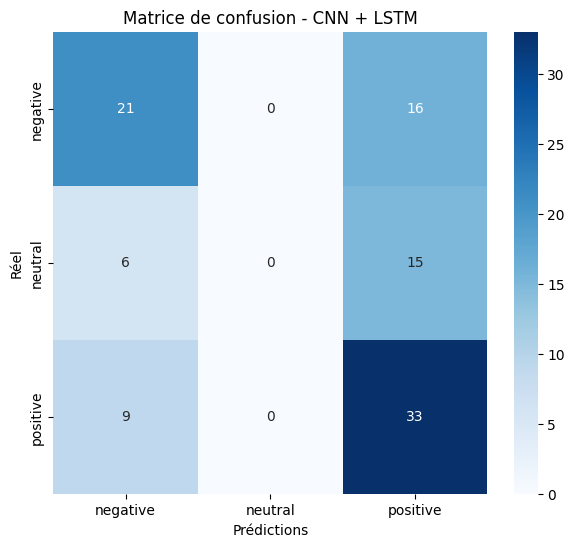

In [42]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_
)

plt.xlabel("Prédictions")

plt.ylabel("Réel")

plt.title(
    "Matrice de confusion - CNN + LSTM"
)

plt.show()

# **BILSTM**

In [49]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Input,

    Embedding,

    LSTM,

    Bidirectional,

    Dense,

    Dropout
)

In [50]:
model_bilstm = Sequential([

    # INPUT
    Input(shape=(MAX_LEN,)),

    # EMBEDDING
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    # BILSTM
    Bidirectional(

        LSTM(
            128
        )
    ),

    # DROPOUT
    Dropout(0.5),

    # DENSE
    Dense(
        64,
        activation='relu'
    ),

    # OUTPUT
    Dense(
        3,
        activation='softmax'
    )
])

In [52]:
model_bilstm.compile(

    loss='categorical_crossentropy',

    optimizer='adam',

    metrics=['accuracy']
)
model_bilstm.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,559,811 (5.95 MB)

 Trainable params: 1,559,811 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history_bilstm = model_bilstm.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 628ms/step - accuracy: 0.4500 - loss: 1.0737 - val_accuracy: 0.3625 - val_loss: 1.0870
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 440ms/step - accuracy: 0.4406 - loss: 1.0354 - val_accuracy: 0.3750 - val_loss: 1.0592
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.6562 - loss: 0.9847 - val_accuracy: 0.5500 - val_loss: 0.9959
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.6750 - loss: 0.8237 - val_accuracy: 0.6250 - val_loss: 0.9028
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 490ms/step - accuracy: 0.7594 - loss: 0.5992 - val_accuracy: 0.5875 - val_loss: 0.9833
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - accuracy: 0.8687 - loss: 0.4728 - val_accuracy: 0.6375 - val_loss: 0.8996
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.9187 - loss: 0.3205 - val_accuracy: 0.6125 - val_loss: 0.9051
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 488ms/step - accuracy: 0.9656 - loss: 0.1528 - val_accuracy: 0

In [54]:
loss, accuracy = model_bilstm.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy :",
    accuracy
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.6000 - loss: 1.7272
Test Accuracy : 0.6000000238418579


In [55]:
y_pred_probs_bilstm = model_bilstm.predict(
    X_test
)
y_pred_bilstm = np.argmax(
    y_pred_probs_bilstm,
    axis=1
)

y_true_bilstm = np.argmax(
    y_test,
    axis=1
)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step


In [56]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_true_bilstm,

        y_pred_bilstm,

        target_names=label_encoder.classes_,

        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.71      0.59      0.65        37
     neutral       0.38      0.43      0.40        21
    positive       0.64      0.69      0.67        42

    accuracy                           0.60       100
   macro avg       0.58      0.57      0.57       100
weighted avg       0.61      0.60      0.60       100



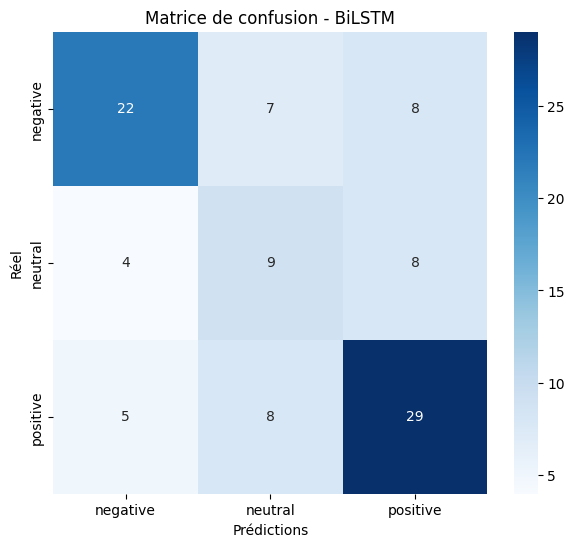

In [57]:
from sklearn.metrics import confusion_matrix

cm_bilstm = confusion_matrix(
    y_true_bilstm,
    y_pred_bilstm
)
plt.figure(figsize=(7,6))

sns.heatmap(

    cm_bilstm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_
)

plt.xlabel("Prédictions")

plt.ylabel("Réel")

plt.title(
    "Matrice de confusion - BiLSTM"
)

plt.show()

# **Comparaison entre LSTM Simple , LSTM+CNN et BILSTM**

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)





lstm_accuracy = accuracy_score(
    y_true_lstm,
    y_pred_lstm
)

lstm_precision = precision_score(
    y_true_lstm,
    y_pred_lstm,
    average='weighted'
)

lstm_recall = recall_score(
    y_true_lstm,
    y_pred_lstm,
    average='weighted'
)

lstm_f1 = f1_score(
    y_true_lstm,
    y_pred_lstm,
    average='weighted'
)



cnn_lstm_accuracy = accuracy_score(
    y_true,
    y_pred
)

cnn_lstm_precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

cnn_lstm_recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

cnn_lstm_f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)



bilstm_accuracy = accuracy_score(
    y_true_bilstm,
    y_pred_bilstm
)

bilstm_precision = precision_score(
    y_true_bilstm,
    y_pred_bilstm,
    average='weighted'
)

bilstm_recall = recall_score(
    y_true_bilstm,
    y_pred_bilstm,
    average='weighted'
)

bilstm_f1 = f1_score(
    y_true_bilstm,
    y_pred_bilstm,
    average='weighted'
)



results_dl = pd.DataFrame({

    'Model': [
        'LSTM',
        'CNN + LSTM',
        'BiLSTM'
    ],

    'Accuracy': [
        lstm_accuracy,
        cnn_lstm_accuracy,
        bilstm_accuracy
    ],

    'Precision': [
        lstm_precision,
        cnn_lstm_precision,
        bilstm_precision
    ],

    'Recall': [
        lstm_recall,
        cnn_lstm_recall,
        bilstm_recall
    ],

    'F1-score': [
        lstm_f1,
        cnn_lstm_f1,
        bilstm_f1
    ]
})

print(results_dl)

        Model  Accuracy  Precision  Recall  F1-score
0        LSTM      0.43   0.548182    0.43  0.269686
1  CNN + LSTM      0.54   0.432396    0.54  0.474386
2      BiLSTM      0.60   0.611997    0.60  0.603412


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
